In [44]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import os
from tqdm import tqdm

from torchvision.transforms import v2

from utils import preprocessing_remove_lines, is_char_correct_with_allowance, split_into_char_images

In [45]:
source_folder = "test/"
captcha_files = [f for f in os.listdir(source_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {source_folder}")

# Setup GPU

In [46]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Setup Character Classification ANN Model
The model class must be same as the trained model, probably should be moved to its own .py file

In [49]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

class Model(nn.Module):
    def __init__(self, input_shape=(1, 42, 42), latent_channel=128, token_count=2, embed_dim=128): # Actual token count is token_count * token_count
        super().__init__()
        self.features = Featuriser(input_channel=input_shape[0], output_channel=latent_channel)
        self.token_count = token_count
        self.cnn_out_shape = self._get_conv_output_shape(input_shape)
        self.proj = nn.Sequential(
            nn.Linear(latent_channel * (self.cnn_out_shape[-1] // token_count) * (self.cnn_out_shape[-2] // token_count), embed_dim),
            nn.LayerNorm(embed_dim), 
            nn.ReLU()
        )
        self.positional_embedding = RotaryPositionalEmbedding(embed_dim, max_seq_len=token_count*token_count)
        self.attn = SelfAttention(embed_dim=embed_dim, num_heads=4, ff_dim=embed_dim*4, dropout=0.1)
        self.classifier = Classifier(input_features=embed_dim, num_classes=num_classes)
        

    def forward(self, x):
        # x: [B, 1, 42, 42]
        x = self.features(x)
        # x: [B, latent_channel, H', W']

        x = self.split_latent(x, n = self.token_count)
        # x: [B, n*n, latent_channel, H'//n, W'//n]

        x = x.view(x.shape[0], x.shape[1], -1)
        # x: [B, n*n, latent_channel * H'//n * W'//n]
        
        tokens = self.proj(x)
        # x: [B, n*n, embed_dim]

        tokens = self.positional_embedding(tokens)
        # x: [B, n*n, embed_dim]

        x = self.attn(tokens)
        # x: [B, n*n, embed_dim]

        x_pooled = x.mean(dim=1)
        # x: [B, embed_dim]

        x = self.classifier(x_pooled)
        return x
    
    def split_latent(self, x, n):
        B, C, H, W = x.shape
        assert H % n == 0 and W % n == 0, "H and W must be divisible by n"

        # Step 1: reshape to split height and width into n parts
        x = x.view(B, C, n, H // n, n, W // n)  # (B, latent_channel, n, H//n, n, W//n)
        
        # Step 2: rearrange dimensions to bring patches together
        x = x.permute(0, 2, 4, 1, 3, 5)         # (B, n, n, latent_channel, H//n, W//n)
        
        # Step 3: flatten n×n patches into one dimension
        x = x.reshape(B, n * n, C, H // n, W // n)  # (B, n*n, latent_channel, H//n, W//n)
        
        return x
    
    def _get_conv_output_shape(self, input_shape):
        """Pass a dummy input to conv layers to compute flatten size"""
        with torch.no_grad():
            x = torch.zeros(1, *input_shape)
            x = self.features(x)
            return x.shape
    
class Classifier(nn.Module):
    def __init__(self, input_features, num_classes):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_features, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(x)

import torch
import torch.nn as nn

class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_seq_len=2048):
        super().__init__()
        assert d_model % 2 == 0, "d_model must be even for RoPE"

        position = torch.arange(max_seq_len, dtype=torch.float32).unsqueeze(1)
        dim = torch.arange(0, d_model, 2, dtype=torch.float32)

        # Calculate frequencies (like in Transformers)
        inv_freq = 1.0 / (10000 ** (dim / d_model))
        sinusoid_inp = position * inv_freq

        self.register_buffer("sin", torch.sin(sinusoid_inp))
        self.register_buffer("cos", torch.cos(sinusoid_inp))

    def forward(self, x):
        """
        x: [batch_size, seq_len, d_model]
        """
        seq_len = x.size(1)
        sin, cos = self.sin[:seq_len, :], self.cos[:seq_len, :]

        # Split even and odd features
        x1 = x[..., ::2]
        x2 = x[..., 1::2]

        # Apply rotation
        x_rot = torch.stack(
            [x1 * cos - x2 * sin, x1 * sin + x2 * cos],
            dim=-1
        )

        return x_rot.flatten(-2)

class SelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4, ff_dim=None, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True, dropout=dropout)
        self.attn_norm = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim or embed_dim*4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim or embed_dim*4, embed_dim),
            nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(embed_dim)

    def forward(self, x, key_padding_mask=None):
        attn_out, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask)
        x = self.attn_norm(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.ffn_norm(x + ffn_out)
        return x
    
class Featuriser(nn.Module):
    def __init__(self, input_channel, output_channel):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(input_channel, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2),
            nn.Dropout(0.05),

            ConvBlock(32, 64),
            ConvBlock(64, 64),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            ConvBlock(64, output_channel),
            nn.Dropout(0.25),
        )

    def forward(self, x):
        x = self.features(x)
        return x
    
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

net = torch.load("char_classification_transformer_v2_model.pth", map_location=device, weights_only=False)
net.to(device)
net.eval()

36


Model(
  (features): Featuriser(
    (features): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
      )
      (1): ConvBlock(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
      )
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Dropout(p=0.05, inplace=False)
      (4): ConvBlock(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
      )
      (5): ConvBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNo

# Captcha Seperation

### Test split images

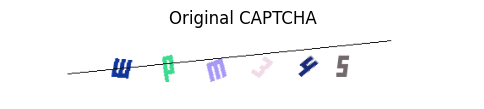

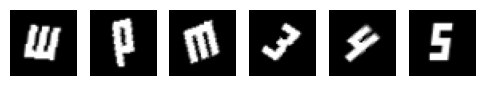

In [50]:
test_captcha_idx = 101 #18
test_captcha = cv2.imread(os.path.join(source_folder, captcha_files[test_captcha_idx]))
test_captcha_filename = captcha_files[test_captcha_idx]
test_char_images = split_into_char_images(test_captcha)

# Display char images side by side
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(test_captcha, cv2.COLOR_BGR2RGB))  # Convert BGR → RGB
plt.title("Original CAPTCHA")
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 3))
for i, char_img in enumerate(test_char_images):
    plt.subplot(1, len(test_char_images), i + 1)
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

# Character Detection

In [51]:
def predict(y_pred_logits): 
    # Take the index of the highest logit for each sample
    y_pred = torch.argmax(y_pred_logits, dim=1) # Note: returns a tensor
    return y_pred

def predict_single_char_image(net, img, char_classes):
    # Preprocess img with cv2 resize if incorrect size
    if img.shape[0] != 42 or img.shape[1] != 42:
        img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

    # Normalize and convert to tensor
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)   # (1, 42, 42)
    img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

    net.eval()
    with torch.no_grad():
        output = net(img_tensor)
        predicted_class = predict(output).item()

    # Map index back to character
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[predicted_class]

    return predicted_label

def predict_single_char_image_with_variants(net, img, char_classes, variants=False, show=False):
    """
    Predicts a single character image using multiple augmentations:
    - original
    - inverted color
    - rotated -30 degrees
    - rotated +30 degrees
    Returns the most confident prediction.
    """

    # Predict single image and give prediction + confidence
    def predict_variant(img_variant):
        # Resize if needed
        if img_variant.shape[0] != 42 or img_variant.shape[1] != 42:
            img_variant = cv2.resize(img_variant, (42, 42), interpolation=cv2.INTER_LINEAR)

        # Normalize and tensorize
        img_variant = img_variant.astype('float32') / 255.0
        img_variant = np.expand_dims(img_variant, axis=0)   # (1, 42, 42)
        img_tensor = torch.tensor(img_variant, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

        # Predict logits and confidence
        net.eval()
        with torch.no_grad():
            output = net(img_tensor)
            probs = F.softmax(output, dim=1)
            confidence, predicted_class = torch.max(probs, dim=1)

        return predicted_class.item(), confidence.item()

    # If we do not want to use variants, just predict the original img
    if not variants:
        pred_idx, _ = predict_variant(img)
        # Map index to label
        inv_char_classes = {v: k for k, v in char_classes.items()}
        predicted_label = inv_char_classes[pred_idx]
        
        if show:
            plt.imshow(img, cmap='gray')
            plt.title(f"Pred: {predicted_label}")
        return predicted_label
    
    # --- Create variants ---
    variants = {
        "original": img,
        "inverted": 255 - img,
        #"rot_-15": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), -15, 1.0), (img.shape[1], img.shape[0])),
        #"rot_+15": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 15, 1.0), (img.shape[1], img.shape[0])),
        #"scale_80": cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), 0, 0.8), (img.shape[1], img.shape[0])),
    }

    # --- Evaluate each variant ---
    best_pred = None
    best_conf = -1
    best_key = None
    preds_conf = {}

    # --- Predict each variant ---
    for key, variant in variants.items():
        pred_idx, conf = predict_variant(variant)
        preds_conf[key] = (pred_idx, conf)
        if conf > best_conf:
            best_conf = conf
            best_pred = pred_idx
            best_key = key

    # Map index to label
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[best_pred]

    # --- Plot all variants side by side (if show = True) ---
    if show:
        print(f"Best prediction: {predicted_label} ({best_key}, conf={best_conf:.2f})")
        plt.figure(figsize=(12, 3))
        for i, (key, variant) in enumerate(variants.items()):
            pred_idx, conf = preds_conf[key]
            label = inv_char_classes[pred_idx]
            plt.subplot(1, len(variants), i + 1)
            plt.imshow(variant, cmap='gray')
            plt.title(f"{key}\nPred: {label}\nConf: {conf:.2f}")
            plt.axis('off')
        plt.show()

    return predicted_label

def predict_char_images(net, char_images, char_classes, show=False):
    output = []
    for char_img in char_images:
        output.append(predict_single_char_image_with_variants(net, char_img, char_classes, show=show))

    return output

### Test character detection

wpm345-0.png
['w', 'p', 'm', '3', '4', '5']


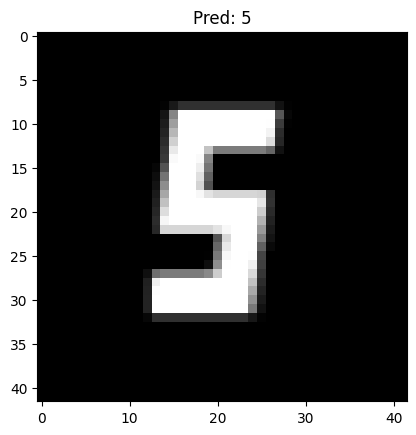

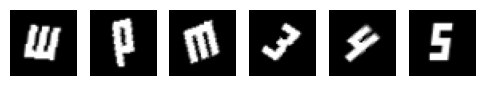

In [52]:
# Display predictions
print(test_captcha_filename)
print(predict_char_images(net, test_char_images, char_classes, show=True))

# Display char images
plt.figure(figsize=(6, 3))
for i, char_img in enumerate(test_char_images):
    plt.subplot(1, len(test_char_images), i + 1)
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

# Compute Metrics

### Run Test Pipeline on Test Data

In [53]:
test_folder = "test/" # "clean_test/"
captcha_files = [f for f in os.listdir(test_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {test_folder}")

images_count = 0
wrong_char_num_count = 0
correct = 0
correct_with_allowance = 0

character_count = 0
correct_char_count = 0
correct_char_count_with_allowance = 0

for (root,dirs,files) in os.walk(test_folder,topdown=True):
    for file in tqdm(files, desc="Loading images"):
        if file.ednswith('.Identifier'):
            os.remove(os.path.join(root, file))
            continue
        if file.endswith('.png'):
            if file[1] == "_":
                os.remove(os.path.join(root, file))
                continue
            if len(file.split("-")[1].split(".png")[0]) != 1: # remove any images marked wrong (train data)
                #print(file)
                continue

            images_count += 1
            
            correct_char_array = list(file.split("-")[0])
            character_count += len(correct_char_array)
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            char_images = split_into_char_images(img)
            predicted_char_array = predict_char_images(net, char_images, char_classes)

            correct_char_count += sum(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array))
            correct_char_count_with_allowance += sum(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array))
            
            # Wrong number of characters
            if len(correct_char_array) != len(predicted_char_array):
                wrong_char_num_count += 1
                continue

            # All correct
            if all(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct += 1
                correct_with_allowance += 1
                continue

            # ALl correct only with allowance
            if all(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct_with_allowance += 1
                continue

print(f'Captcha count: {images_count}')
print(f'Wrong number of characters: {wrong_char_num_count} ({(wrong_char_num_count / images_count * 100):.2f}%)')
print(f'Correct: {correct} ({(correct / images_count * 100):.2f}%)')
print(f'Correct with allowance: {correct_with_allowance} ({(correct_with_allowance / images_count * 100):.2f}%)')
print("")
print(f'Total character count: {character_count}')
print(f'Correct characters: {correct_char_count} ({(correct_char_count / character_count * 100):.2f}%)')
print(f'Correct characters with allowance: {correct_char_count_with_allowance} ({(correct_char_count_with_allowance / character_count * 100):.2f}%)')

Loading images: 100%|█████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 32.89it/s]

Captcha count: 2001
Wrong number of characters: 93 (4.65%)
Correct: 1428 (71.36%)
Correct with allowance: 1759 (87.91%)

Total character count: 12015
Correct characters: 10994 (91.50%)
Correct characters with allowance: 11421 (95.06%)
